In [1]:
import numpy as np
import matplotlib.pyplot as plt
import midpoints_analysis as mpa
import plot_helpers as ph
from pathlib import Path
import json
import gzip

In [2]:
path_MD_data = Path('/Users/lisepauwels/sps_simulations/MD_data/20250616/')
path_study_results = Path("/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/IntensityScan2/study_results")
name_files = [p.name for p in path_study_results.iterdir()]

In [3]:
sweep_per_turn = 1.0
data_simulations = {'linear' : {}, 'errors': {}}
for name_file in name_files:
    with gzip.open(path_study_results / name_file, "rt") as f:
        study_results = json.load(f)

    line_type = name_file.split("_")[1]
    chroma = float(name_file.split("_")[2].split(".json")[0])
    print(line_type, chroma)
    if chroma not in data_simulations[line_type]:
        data_simulations[line_type][chroma] = {}
    
    for plane in list(study_results.keys()):
        assert abs(study_results[plane]['sweep_per_turn']) == sweep_per_turn
        turns, counts = np.unique(study_results[plane]['at_turn'], return_counts=True)
        data_simulations[line_type][chroma][plane] = {'turns' : turns, 'counts' : counts}

errors 0.1
linear -0.2
errors -0.1
linear 0.3
errors -1.5
errors 1.5
linear 1.1
errors -0.7
linear 0.8
errors 0.7
linear -0.4
errors 1.3
linear -1.0
linear 0.5
linear -0.9
errors -1.3
linear -0.3
errors 0.0
errors -1.4
linear 0.2
errors 1.4
errors -0.6
linear 1.0
linear -0.5
linear 0.9
errors 0.6
linear -1.1
errors 1.2
errors -1.2
linear -0.8
linear 0.4
linear 1.5
errors -0.3
errors 0.3
linear -1.4
linear 0.1
errors 0.5
linear -0.6
linear 1.3
errors -0.5
linear 0.7
errors 0.8
errors -1.1
errors 1.1
errors -0.8
linear -1.2
errors -0.2
linear 1.4
linear -0.1
errors 0.2
linear -1.5
linear 0.0
linear -0.7
errors 0.4
errors -0.4
linear 1.2
errors -1.0
linear 0.6
errors 0.9
linear -1.3
errors -0.9
errors 1.0


In [4]:
normalised_intensity = {}
num_particles = 2000 * 500
for line_type in ['linear', 'errors']:
    normalised_intensity[line_type] = {}
    for chroma in sorted(data_simulations[line_type].keys()):
        normalised_intensity[line_type][chroma] = {}
        for plane in ['DPpos', 'DPneg']:
            turns = data_simulations[line_type][chroma][plane]['turns']
            counts = data_simulations[line_type][chroma][plane]['counts']

            turns = np.concatenate(([0], turns))
            counts = np.concatenate(([0], counts))

            deltas = mpa.df_to_delta(turns * sweep_per_turn)
            if plane == 'DPneg':
                deltas = -deltas
            
            normalised_intensity[line_type][chroma][plane] = {'deltas': deltas, 'values': 1 - np.cumsum(counts) / num_particles}

In [5]:
midpoints1 = mpa.get_midpoints(normalised_intensity, percentile=0.1)
midpoints2 = mpa.get_midpoints(normalised_intensity, percentile=0.9)

In [6]:
midpoints = mpa.get_midpoints(normalised_intensity, percentile=0.5)

In [7]:
with open(path_MD_data/'midpoints_MD.json') as f:
    midpoints_md = json.load(f)

In [8]:
midpoints_md = mpa.restructure_md_midpoints(midpoints_md)

In [9]:
savepath = Path('/Users/lisepauwels/sps_simulations/Studies/MomentumAcceptance/IntensityScan2/Figures/')

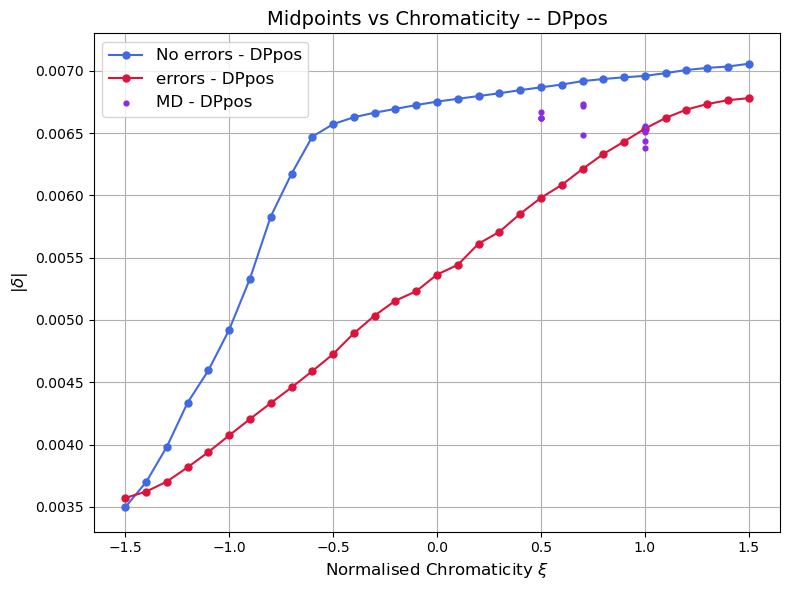

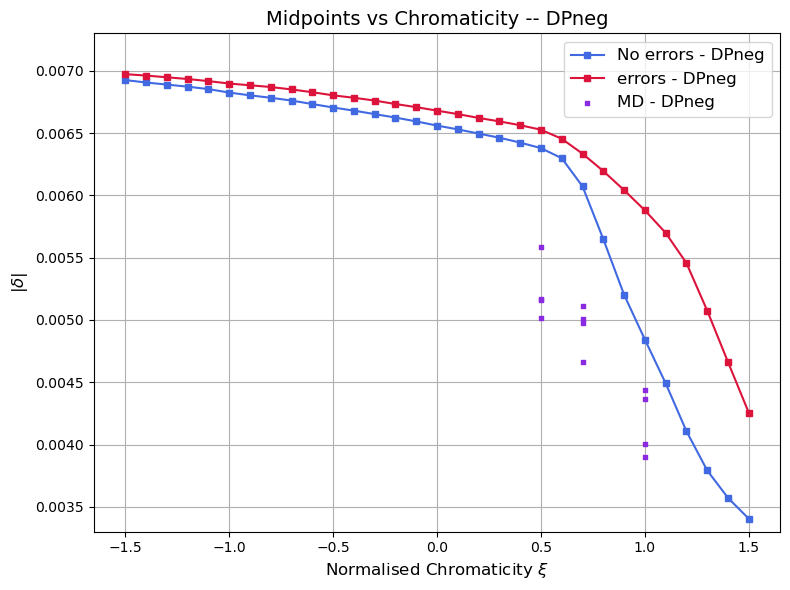

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Midpoints vs Chromaticity -- DPneg'}, xlabel='Normalised Chromaticity $\\xi$', ylabel='$|\\delta|$'>)

In [10]:
colours = {'linear' :  'royalblue', 'errors': 'crimson', 'MD': 'blueviolet'}
mpa.plot_midpoints(midpoints, midpoints_md, colours=colours, planes = ['DPpos'],ylim = (0.0033, 0.0073), savefig=savepath/'midpoints_DPpos.png')
mpa.plot_midpoints(midpoints, midpoints_md, colours=colours, planes = ['DPneg'],ylim = (0.0033, 0.0073), savefig=savepath/'midpoints_DPneg.png')

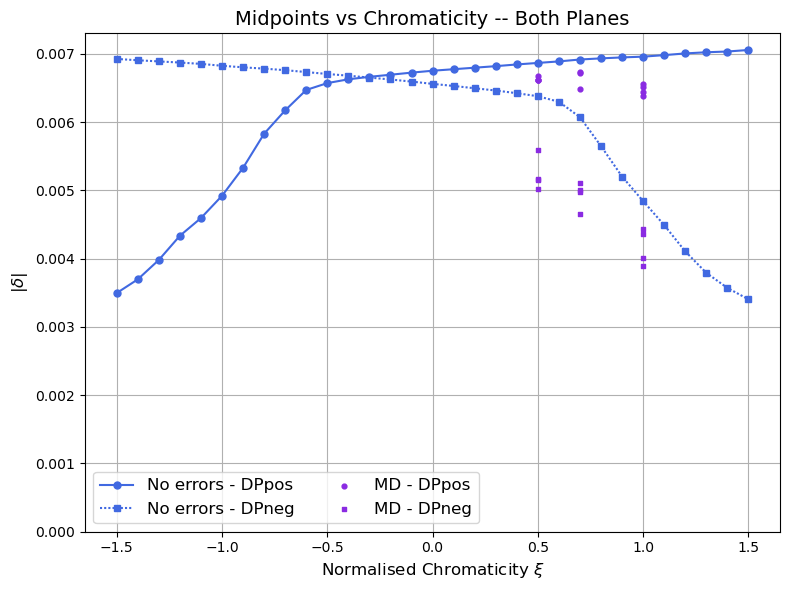

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Midpoints vs Chromaticity -- Both Planes'}, xlabel='Normalised Chromaticity $\\xi$', ylabel='$|\\delta|$'>)

In [17]:
colours = {'linear' :  'royalblue', 'errors': 'crimson', 'MD': 'blueviolet'}
line_types = ['linear']
ylim = (0.00, 0.0073)
# ylim = (0.0, 0.0083)
mpa.plot_midpoints(midpoints, midpoints_md=midpoints_md, colours=colours, planes = ['DPpos', 'DPneg'], line_types=line_types, ylim = ylim)#, savefig=savepath/'midpoints_lin.png')

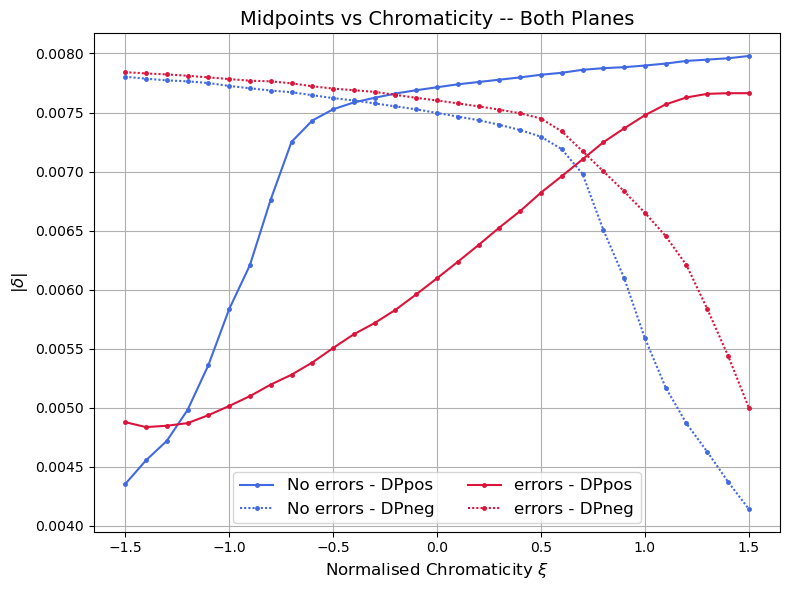

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Midpoints vs Chromaticity -- Both Planes'}, xlabel='Normalised Chromaticity $\\xi$', ylabel='$|\\delta|$'>)

In [12]:
colours = {'linear' :  'royalblue', 'errors': 'crimson', 'MD': 'blueviolet'}
# line_types = ['linear']
ylim = (0.0033, 0.0073)
ylim = (0.0, 0.0073)
mpa.plot_midpoints(midpoints1, colours=colours, planes = ['DPpos', 'DPneg'],  ylim = None)#, savefig=savepath/'midpoints_lin.png')

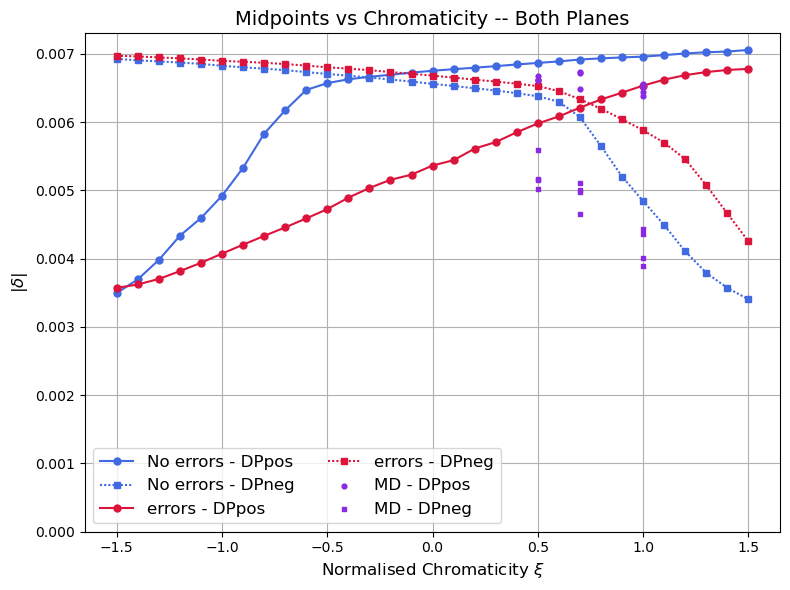

(<Figure size 800x600 with 1 Axes>,
 <Axes: title={'center': 'Midpoints vs Chromaticity -- Both Planes'}, xlabel='Normalised Chromaticity $\\xi$', ylabel='$|\\delta|$'>)

In [13]:
colours = {'linear' :  'royalblue', 'errors': 'crimson', 'MD': 'blueviolet'}
line_types = ['linear', 'errors']
ylim = (0.0033, 0.0073)
ylim = (0.0, 0.0073)
mpa.plot_midpoints(midpoints, midpoints_md, colours=colours, planes = ['DPpos', 'DPneg'], line_types=line_types, ylim = ylim, savefig=savepath/'midpoints.png')

(0.0, 0.0138)

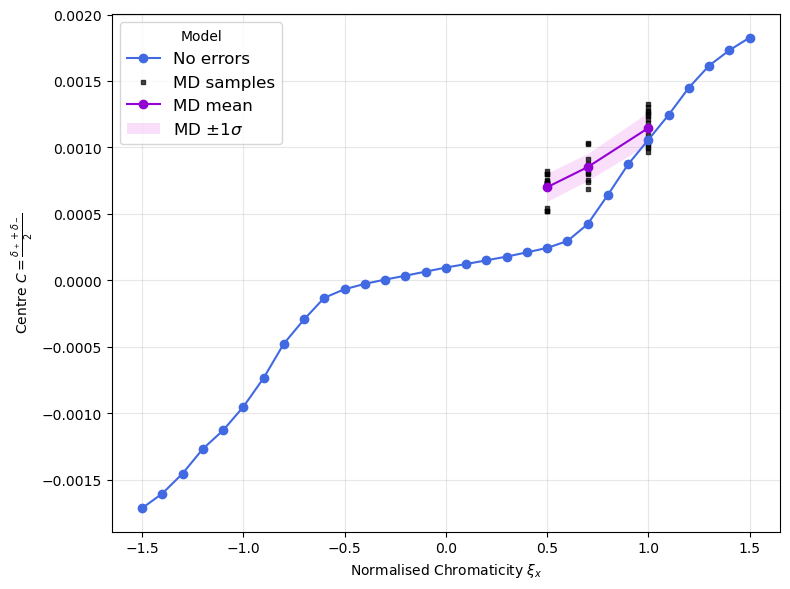

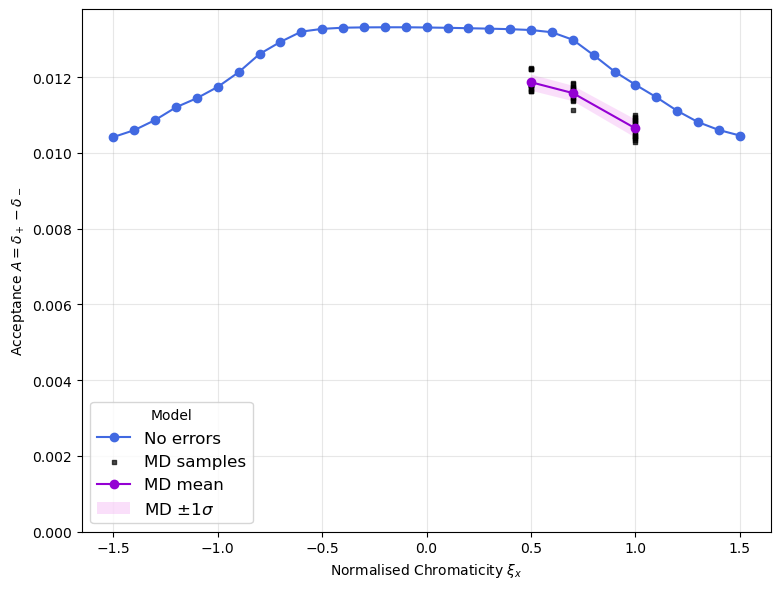

In [14]:
import midpoints_analysis as mpa
import acceptance_centers as ac
colours = {'linear' : 'royalblue', 'errors': 'crimson', 'MD_means' : 'darkviolet', 'MD_stds' : 'violet'}
intensity_midpoints = mpa.get_midpoints(normalised_intensity)
ac.plot_centers(intensity_midpoints=intensity_midpoints, line_types = ['linear'], colours= colours, md_midpoints=midpoints_md)#, savefig='centers_vs_chroma.png')
fig, ax = ac.plot_acceptance(intensity_midpoints, line_types = ['linear'], colours= colours, md_midpoints=midpoints_md)#, savefig='acceptance_vs_chroma.png')
ax.set_ylim(0.0, 0.0138)

(0.0, 0.0138)

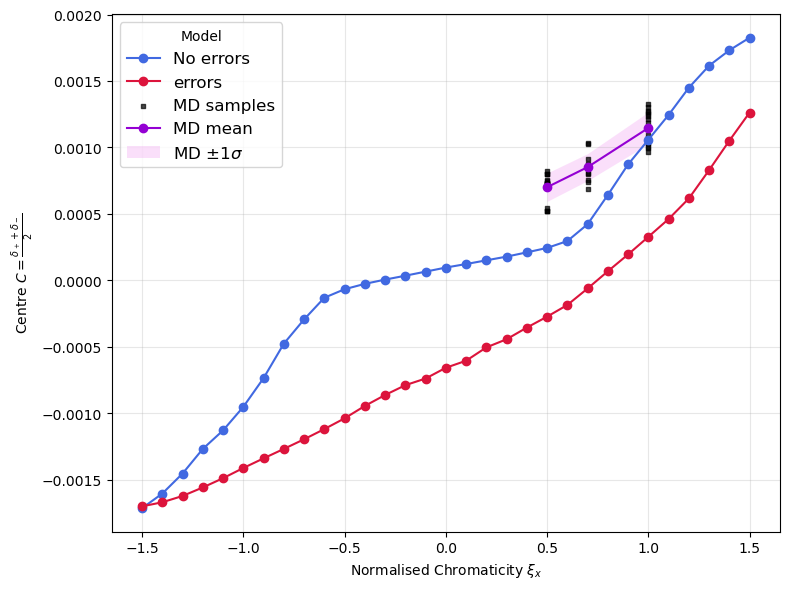

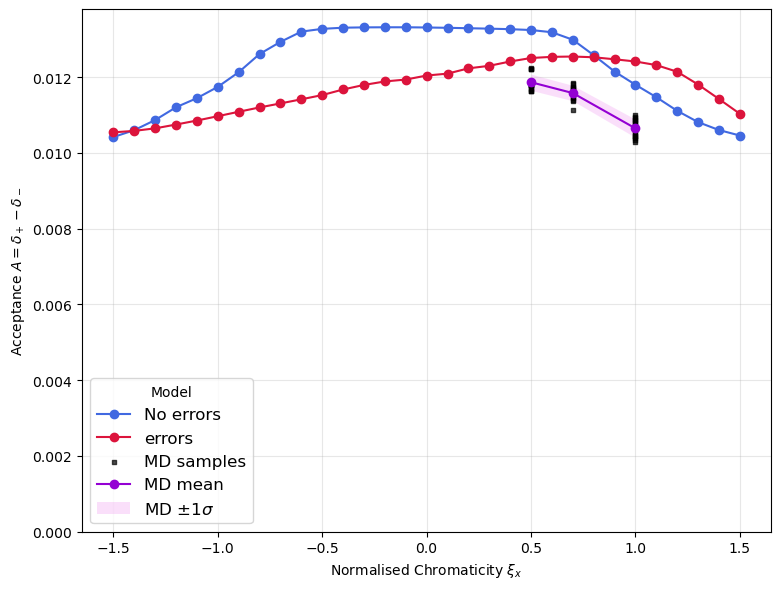

In [18]:
import midpoints_analysis as mpa
import acceptance_centers as ac
colours = {'linear' : 'royalblue', 'errors': 'crimson', 'MD_means' : 'darkviolet', 'MD_stds' : 'violet'}
intensity_midpoints = mpa.get_midpoints(normalised_intensity)
ac.plot_centers(intensity_midpoints=intensity_midpoints, line_types = ['linear', 'errors'], colours= colours, md_midpoints=midpoints_md)#, savefig='centers_vs_chroma.png')
fig, ax = ac.plot_acceptance(intensity_midpoints, line_types = ['linear', 'errors'], colours= colours, md_midpoints=midpoints_md)#, savefig='acceptance_vs_chroma.png')
ax.set_ylim(0.0, 0.0138)

In [21]:
normalised_intensity['linear'][1.5]['DPpos']

{'deltas': array([0.        , 0.00464175, 0.00466126, ..., 0.01566485, 0.01579309,
        0.01672702], shape=(1446,)),
 'values': array([1.      , 0.999999, 0.999998, ..., 0.002536, 0.002535, 0.      ],
       shape=(1446,))}

In [22]:
20.13 + 1.5*0.01672702

20.15509053